In [4]:
import os
import torch
import pandas as pd
import scanpy as sc
from preprocess import *
from utils import *
import numpy as np
import matplotlib.pyplot as plt
import harmonypy as hm

from train import Train
from pathlib import Path

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [3]:
savepath = 'Result'
if not os.path.exists(savepath):
    os.mkdir(savepath)

In [6]:
ROOT_PATH = Path('../../../data/MBA-MBP')
DATA_NAME = 'Mouse_Brain_Anterior'
adata_anterior = sc.read_visium(ROOT_PATH / DATA_NAME, count_file=DATA_NAME + "_filtered_feature_bc_matrix.h5")
adata_anterior.var_names_make_unique()

spatial_a=pd.read_csv("../../../data/MBA-MBP/Mouse_Brain_Anterior/spatial/tissue_positions_list.csv",
                    sep=",",header=None,na_filter=False,index_col=0)
adata_anterior.obs["x_array"]=spatial_a[2]
adata_anterior.obs["y_array"]=spatial_a[3]
adata_anterior.obs["x_pixel"]=spatial_a[4]
adata_anterior.obs["y_pixel"]=spatial_a[5]
adata_anterior.obs['boundary'] = 0
# adata_anterior.obs['x_pixel'] = adata_anterior.obsm['spatial'][:,0]
# adata_anterior.obs['y_pixel'] = adata_anterior.obsm['spatial'][:,1]
# make spot name unique
adata_anterior.obs_names = [x + '_anterior' for x in adata_anterior.obs_names]

# adata_anterior.layers['count'] = adata_anterior.X.toarray()
# sc.pp.normalize_total(adata_anterior, target_sum=1e6)
# sc.pp.highly_variable_genes(adata_anterior, flavor="seurat_v3", layer='count', n_top_genes=5000)
# adata_anterior = adata_anterior[:, adata_anterior.var['highly_variable'] == True]
# sc.pp.scale(adata_anterior)
# adata_anterior = adata_anterior[:, adata_anterior.var['highly_variable']]
adata_anterior

D:\anaconda\envs\njy\Lib\site-packages\anndata\_core\anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
D:\anaconda\envs\njy\Lib\site-packages\anndata\_core\anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 2695 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [7]:
DATA_NAME = 'Mouse_Brain_Posterior'
adata_posterior = sc.read_visium(ROOT_PATH / DATA_NAME, count_file=DATA_NAME + "_filtered_feature_bc_matrix.h5")
adata_posterior.var_names_make_unique()

spatial_p=pd.read_csv("../../../data/MBA-MBP/Mouse_Brain_Posterior/spatial/tissue_positions_list.csv",
                    sep=",",header=None,na_filter=False,index_col=0)
adata_posterior.obs["x_array"]=spatial_p[2]
adata_posterior.obs["y_array"]=spatial_p[3]
adata_posterior.obs["x_pixel"]=spatial_p[4]
adata_posterior.obs["y_pixel"]=spatial_p[5]
adata_posterior.obs['boundary'] = 0
# adata_posterior.obs['x_pixel'] = adata_posterior.obsm['spatial'][:,0]
# adata_posterior.obs['y_pixel'] = adata_posterior.obsm['spatial'][:,1]
# make spot name unique
adata_posterior.obs_names = [x + '_posterior' for x in adata_posterior.obs_names]

# adata_posterior.layers['count'] = adata_posterior.X.toarray()
# sc.pp.normalize_total(adata_posterior, target_sum=1e6)
# sc.pp.highly_variable_genes(adata_posterior, flavor="seurat_v3", layer='count', n_top_genes=5000)
# adata_posterior = adata_posterior[:, adata_posterior.var['highly_variable'] == True]
# sc.pp.scale(adata_posterior)
# adata_posterior = adata_posterior[:, adata_posterior.var['highly_variable']]
adata_posterior

D:\anaconda\envs\njy\Lib\site-packages\anndata\_core\anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
D:\anaconda\envs\njy\Lib\site-packages\anndata\_core\anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 3355 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [8]:
obs_a = adata_anterior.obs
obs_p = adata_posterior.obs
# obs_p["x_pixel"]=obs_p["x_pixel"]-np.min(obs_p["x_pixel"])+np.min(obs_a["x_pixel"])
obs_p["y_pixel"] = obs_p["y_pixel"] - np.min(obs_p["y_pixel"]) + np.max(obs_a["y_pixel"]) - 150
# obs_p["y_pixel"] = obs_p["y_pixel"] - np.min(obs_p["y_pixel"]) + np.max(obs_a["y_pixel"]) + 1500

obs_a["boundary"] = 0
obs_p["boundary"] = 0

for i in list(set(obs_a['x_array'])):
    j = obs_a[obs_a['x_array'] == i].max()["y_array"]
    temp = obs_a[obs_a['x_array'] == i]
    temp = temp[temp['y_array'] == j].index
    obs_a.loc[temp, "boundary"] = 1

for i in list(set(obs_p['x_array'])):
    j = obs_p[obs_p['x_array'] == i].min()["y_array"]
    temp = obs_p[obs_p['x_array'] == i]
    temp = temp[temp['y_array'] == j].index
    obs_p.loc[temp, "boundary"] = 1

mean_a_y = obs_a[obs_a["boundary"] == 1]['x_pixel'].mean()
mean_p_y = obs_p[obs_p["boundary"] == 1]['x_pixel'].mean()
obs_p['x_pixel'] = obs_p['x_pixel'] + mean_a_y - mean_p_y

In [9]:
adata_anterior.obsm["spatial_aligned"] = adata_anterior.obs.loc[adata_anterior.obs_names, ['x_pixel', "y_pixel"]].to_numpy()
adata_posterior.obsm["spatial_aligned"] = adata_posterior.obs.loc[adata_posterior.obs_names, ['x_pixel', "y_pixel"]].to_numpy()

In [10]:
list_adata = [adata_anterior, adata_posterior]

In [11]:
import anndata as ad
pre_adata = ad.concat(list_adata, label="batch_name", keys=['anterior', 'posterior'])
pre_adata.obs["batch_name"] = pre_adata.obs["batch_name"].astype('category')
pre_adata

AnnData object with n_obs × n_vars = 6050 × 32285
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary', 'batch_name'
    obsm: 'spatial', 'spatial_aligned'

In [12]:
slice_name_list = list(pre_adata.obs['batch_name'].unique())
slice_name_list

['anterior', 'posterior']

In [13]:
datasets_df = pd.DataFrame([['anterior', 'posterior'],])
datasets_df.index = ['Sample1']
datasets_df.columns = ['Location1', 'Location2']
batch_tag = 'Sample1'
datasets = datasets_df.loc[batch_tag].values    # Sample
# datasets = datasets_df[batch_tag].values        # Location
dataset_tags = datasets

n_neighbor = 5
n_cluster = 32 if batch_tag != 'Sample2' else 5

epochs = 500
coord_type = 'spatial'
weights = [[60, 0.01, 0.01]]

adata_list = []

for i, proj_name in enumerate(slice_name_list):
    dataset = proj_name
    # print(dataset)
    # file_fold = '../../../data/MBA-MBP/' + str(dataset)
    # adata = sc.read_visium(file_fold, count_file=dataset + '_filtered_feature_bc_matrix.h5', load_images=True)
    # adata.var_names_make_unique()

    # add ground_truth
    # df_meta = pd.read_csv(file_fold + '/manual_annotations.txt', sep='\t', header=None, index_col=0)
    # df_meta.columns = ['layer_guess']
    # adata.obs['ground_truth'] = df_meta['layer_guess'].values
    # # filter out NA nodes
    # adata = adata[~pd.isnull(adata.obs['ground_truth'])]

    adata = pre_adata[pre_adata.obs['batch_name'] == slice_name_list[i]]

    adata.obs_names = [x + '_' + dataset for x in adata.obs_names]
    adata.obs['batch_name'] = [dataset] * adata.X.shape[0]
    adata_list.append(adata)
    
batch_adata = integrate_adata(adata_list, coord_type=coord_type, n_neighbor=n_neighbor)

Recommended l is 277
Recommended l is 277
AnnData object with n_obs × n_vars = 6050 × 20269
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary', 'batch_name'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'
    obsm: 'spatial', 'spatial_aligned', 'neighbors', 'feature'
    obsp: 'adj'


In [14]:
for mse_weight, graph_weight, nce_weight in weights:
    set = batch_tag + "_" + str(n_neighbor) + "_" + str(mse_weight) + "_" + str(graph_weight) \
        + "_" + str(nce_weight) + "_" + str(epochs)
    print(set)
    print("*" * 70)
    
    model = Train(batch_adata, device=device, epochs=epochs, mse_weight=mse_weight,
                      graph_weight=graph_weight, nce_weight=nce_weight, coord_type=coord_type,
                      n_neighbor=n_neighbor, n_cluster=n_cluster, protocol='10X')
    batch_adata = model.train()

    # Harmony
    data_mat = batch_adata.obsm['emb'].copy()
    vars_use = ['batch_name']
    meta_data = batch_adata.obs[vars_use]
    # Run Harmony
    ho = hm.run_harmony(data_mat, meta_data, vars_use)
    batch_adata.obsm['Harmony_Revised'] = ho.Z_corr.T

    method = 'mclust'  # mclust, leiden, louvain, kmeans
    cluster(batch_adata, n_clusters=n_cluster, method=method, key='Harmony_Revised')

    domain_tag = 'domain'
    embed_tag = 'Harmony_Revised'

    # filter out NA nodes
    #sub_adata = batch_adata[~pd.isnull(batch_adata.obs['ground_truth'])]

    # sc.set_figure_params(vector_friendly=True, figsize=(4.5 / 2.54, 4.5 / 2.54))
    # fig, ax_list = plt.subplots(1, 4, figsize=(5 / 2.54 * 4, 5 / 2.54))
    # ### Plotting UMAP before batch effect correction
    # sc.pp.pca(sub_adata)
    # sc.pp.neighbors(sub_adata, use_rep='X_pca')
    # sc.tl.umap(sub_adata)
    # sc.pl.umap(sub_adata, color='batch_name', title='Uncorrected', ax=ax_list[0], frameon=False,
    #            show=False, size=3, legend_fontsize=5)
    # ### Plotting UMAP after batch effect correction
    # sc.pp.neighbors(sub_adata, use_rep=embed_tag)
    # sc.tl.umap(sub_adata)
    # sc.pl.umap(sub_adata, color='batch_name', ax=ax_list[1], title='Batch corrected', frameon=False,
    #            show=False, size=3, legend_fontsize=5)
    # 
    # sc.pl.umap(sub_adata, color='ground_truth', ax=ax_list[2], title='Ground Truth', frameon=False,
    #            show=False, size=3, legend_fontsize=5)
    # sc.pl.umap(sub_adata, color=domain_tag, ax=ax_list[3], title='Predict Domain', frameon=False,
    #            show=False, size=3, legend_fontsize=5)
    # plt.savefig(savepath + f'SpaGIC_{batch_tag}_umap_hm.png', bbox_inches='tight', dpi=300)
    # # plt.savefig(savepath + f'SpaGIC_{batch_tag}_umap_hm.pdf', bbox_inches='tight', dpi=300)
    # # plt.show()
    # plt.close()

    # scores
    # ARI = adjusted_rand_score(sub_adata.obs['ground_truth'], sub_adata.obs[domain_tag])
    # NMI = normalized_mutual_info_score(sub_adata.obs['ground_truth'], sub_adata.obs[domain_tag])
    # print(f'{batch_tag}, ARI: {ARI}; NMI: {NMI}')

    #### single slice visual
    # sc.set_figure_params(vector_friendly=True, figsize=(3.2 / 2.54, 3.5 / 2.54))
    # fig, axs = plt.subplots(1, len(datasets), figsize=(4.5 * len(datasets), 3))
    # for idx, single_adata in enumerate(adata_list):
    #     single_adata.obs[domain_tag] = batch_adata[batch_adata.obs['batch_name'] == datasets[idx]].obs[domain_tag].values
    #     # filter out NA nodes
    #     sub_adata = single_adata[~pd.isnull(single_adata.obs['ground_truth'])]
    #     refine(sub_adata, radius=50, key=domain_tag)
    #     key = 'domain_refined'
    #     ARI = adjusted_rand_score(sub_adata.obs['ground_truth'], sub_adata.obs[key])
    #     NMI = normalized_mutual_info_score(sub_adata.obs['ground_truth'], sub_adata.obs[key])
    #     print(f'{datasets[idx]}, ARI: {ARI}; NMI: {NMI}')
    #     sc.pl.spatial(sub_adata, img_key="hires", ax=axs[idx], color=key, frameon=False, legend_fontsize=8,
    #                   title=f'{datasets[idx]}_ARI=%.4f-NMI=%.4f' % (ARI, NMI), show=False)
    # plt.savefig(savepath + f'SpaGIC_{batch_tag}_sp_hm.png', bbox_inches='tight', dpi=300)
    # plt.savefig(savepath + f'SpaGIC_{batch_tag}_sp_hm.pdf', bbox_inches='tight', dpi=300)
    # plt.show()
    # plt.close()

Sample1_5_60_0.01_0.01_500
**********************************************************************
Begin to train...


100%|██████████| 500/500 [00:20<00:00, 24.13it/s]
2025-01-07 14:54:40,394 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


Optimization finished!


2025-01-07 14:54:41,799 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-01-07 14:54:41,829 - harmonypy - INFO - Iteration 1 of 10
2025-01-07 14:54:43,081 - harmonypy - INFO - Iteration 2 of 10
2025-01-07 14:54:44,378 - harmonypy - INFO - Iteration 3 of 10
2025-01-07 14:54:45,731 - harmonypy - INFO - Iteration 4 of 10
2025-01-07 14:54:46,950 - harmonypy - INFO - Iteration 5 of 10
2025-01-07 14:54:48,157 - harmonypy - INFO - Iteration 6 of 10
2025-01-07 14:54:49,371 - harmonypy - INFO - Converged after 6 iterations


clustering...


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [16]:
adata1 = batch_adata[batch_adata.obs['batch_name'] == 'anterior']
# sc.pl.spatial(adata1, img_key=None, color=['mclust'], title=[''],
#               legend_loc=None, legend_fontsize=12, show=False, frameon=False,
#               spot_size=100)

In [30]:
df_label = pd.read_csv('../../../data/MBA-MBP/Mouse_Brain_Anterior/manual_annotations.tsv', sep='\t',  index_col=0)
#转换index名称
index = [s + '_anterior_anterior' for s in df_label.index]
df_label.index = index
adata1.obs["layer_guess"] = df_label['ground_truth']

In [31]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score

In [32]:
sub_adata1 = adata1[~pd.isnull(adata1.obs['layer_guess'])]
ARI = ari_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total ARI:{ARI}")

total ARI:0.410224783492976


In [33]:
sub_adata1 = adata1[~pd.isnull(adata1.obs['layer_guess'])]
NMI = nmi_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total NMI:{NMI}")
AMI = ami_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total AMI:{AMI}")
ACC = 1/2 * (NMI + AMI)
print(f"total ACC:{ACC}")

total NMI:0.6867532653102971
total AMI:0.662755509613565
total ACC:0.6747543874619311


In [34]:
sub_adata1 = adata1[~pd.isnull(adata1.obs['layer_guess'])]
HOM = hom_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total HOM:{HOM}")
COM = com_score(sub_adata1.obs['layer_guess'], sub_adata1.obs['mclust'])
print(f"total COM:{COM}")
V = 2 * ((HOM * COM) / (HOM + COM))
print(f"total V:{V}")

total HOM:0.6309193502023541
total COM:0.7534287906766158
total V:0.6867532653102971


D:\anaconda\envs\njy\Lib\site-packages\anndata\_core\anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


[<Axes: xlabel='spatial1', ylabel='spatial2'>]

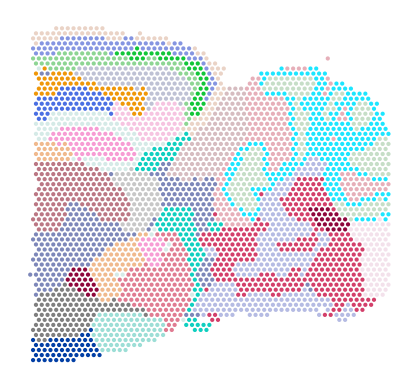

In [36]:
adata2 = batch_adata[batch_adata.obs['batch_name'] == 'posterior']
sc.pl.spatial(adata2, img_key=None, color=['mclust'], title=[''],
              legend_loc=None, legend_fontsize=12, show=False, frameon=False,
              spot_size=100)

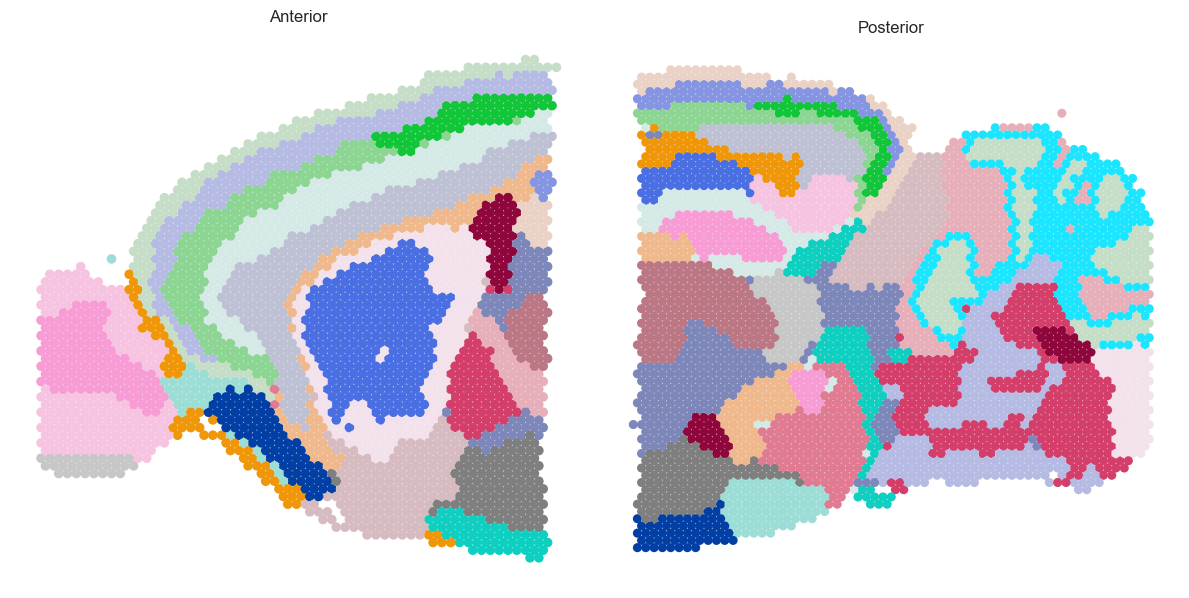

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 绘制第一个批次的空间图
sc.pl.spatial(adata1, ax=axes[0], img_key=None, color=['mclust'], title=['Anterior'],
              legend_loc=None, legend_fontsize=12, show=False, frameon=False,
              spot_size=150)

# 绘制第二个批次的空间图
sc.pl.spatial(adata2, ax=axes[1], img_key=None, color=['mclust'], title=['Posterior'],
              legend_loc=None, legend_fontsize=12, show=False, frameon=False,
              spot_size=150)

# 显示图像
plt.tight_layout()
plt.show()

In [39]:
batch_adata

AnnData object with n_obs × n_vars = 6050 × 20269
    obs: 'in_tissue', 'array_row', 'array_col', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'boundary', 'batch_name', 'mclust', 'domain'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'
    obsm: 'spatial', 'spatial_aligned', 'neighbors', 'feature', 'emb', 'rec_feat', 'Harmony_Revised'
    obsp: 'adj'

D:\anaconda\envs\njy\Lib\site-packages\anndata\_core\anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


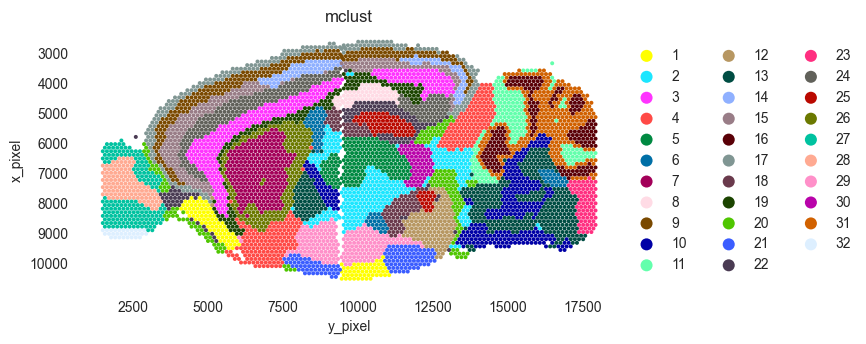

In [41]:
import matplotlib.pyplot as plt

plt.rcParams['axes.facecolor'] = 'white'  # 设置子图的背景颜色
plt.rcParams['figure.facecolor'] = 'white'  # 设置整张图的背景颜色

title = "SpaBatch"
subadata = batch_adata[~batch_adata.obs['mclust'].isna()]  # 删除 NaN
ax=sc.pl.scatter(subadata,alpha=1,x="y_pixel",y="x_pixel",color="mclust",show=False,size=200000/batch_adata.shape[0])
ax.set_aspect('equal', 'box')
ax.axes.invert_yaxis()
plt.grid(False)